# 02_embeddings

Notebook 2 — Embeddings
========================
Extracts all three representations from PDAC_ADJ_Final_Annotated.h5ad
and saves them into a single object for downstream use in Steps 3 & 4.

Representations:
    X_scgpt    (n_cells, 512)   — scGPT zero-shot pretrained embeddings
    X_pca50    (n_cells,  50)   — PCA on scaled 3000 HVGs
    X_raw_hvg  (n_cells, 3000)  — log-normalised HVG expression

Inputs:
    PDAC_ADJ_Final_Annotated.h5ad

Outputs:
    PDAC_ADJ_embeddings.h5ad    — carries all three obsm keys + full obs
    umap_embedding_comparison.png

Runtime: ~10–15 min on Colab T4 GPU (scGPT embedding dominates)


In [ ]:
%%capture
# Install dependencies

!pip uninstall -y torch torchtext torchvision torchaudio numpy scanpy

!pip install "numpy<2" -q
!pip install torch==2.2.2 torchvision==0.17.2 --index-url https://download.pytorch.org/whl/cu121 -q
!pip install --no-deps git+https://github.com/bowang-lab/scGPT.git -q
!pip install "scanpy==1.10.4" wandb -q
!pip install "numpy<2" --force-reinstall --no-deps -q
!pip install --force-reinstall --no-deps torchtext==0.17.2 -q
!pip install scikit-misc -q

print("Restart session")

In [ ]:
# Verify installs after restart
import torch
import numpy as np
import scgpt
import scanpy as sc

print(torch.cuda.is_available())
print(torch.__version__)
print(torch.cuda.get_device_name(0))
print(np.__version__)
print(scgpt.__version__)
print(sc.__version__)

/usr/local/lib/python3.12/dist-packages/scgpt/model/model.py:21: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
/usr/local/lib/python3.12/dist-packages/scgpt/model/multiomic_model.py:19: UserWarning: flash_attn is not installed
  warnings.warn("flash_attn is not installed")
/usr/local/lib/python3.12/dist-packages/scanpy/_utils/__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/usr/local/lib/python3.12/dist-packages/scanpy/__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/usr/local/lib/python3.12/dist-packages/scanpy/readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


True
2.2.2+cu121
Tesla T4
1.26.4
0.2.4
1.10.4


In [ ]:
from pathlib import Path
import os
import scanpy as sc
from google.colab import drive
drive.mount("/content/drive")

DATA_DIR      = Path("/content/drive/MyDrive/CompGenProject/data")
MODEL_DIR     = Path("/content/drive/MyDrive/scGPT_human")   # pretrained weights

ANNOTATED     = DATA_DIR / "PDAC_ADJ_Final_Annotated.h5ad"
OUTPUT_H5AD   = DATA_DIR / "PDAC_ADJ_embeddings.h5ad"
OUTPUT_PLOT   = "umap_embedding_comparison.png"

CELL_TYPE_KEY = "scGPT_target_label"
N_HVG         = 3000
N_PCA_COMPS   = 50
BATCH_SIZE    = 64
RANDOM_STATE  = 42

Mounted at /content/drive


In [ ]:
print("\n── Loading data ─────────────────────────────────────────────────────")
adata = sc.read_h5ad(ANNOTATED)
print(f"  Shape        : {adata.shape}  (cells × genes)")
print(f"  X range      : [{adata.X.min():.3f}, {adata.X.max():.3f}]  (log-normalised)")
print(f"  Conditions   : {adata.obs['condition'].value_counts().to_dict()}")
print(f"  Number of cell types   : {adata.obs[CELL_TYPE_KEY].nunique()}")
print(f"  Sample IDs   : {list(adata.obs['sample_id'].unique())}")
print(f"  Number of PDAC Samples   : {adata[adata.obs['condition'] == 'PDAC'].obs['sample_id'].nunique()}")
print(f"  Number of ADJ Samples   : {adata[adata.obs['condition'] != 'PDAC'].obs['sample_id'].nunique()}")


── Loading data ─────────────────────────────────────────────────────
  Shape        : (71074, 36601)  (cells × genes)
  X range      : [0.000, 9.043]  (log-normalised)
  Conditions   : {'PDAC': 38074, 'ADJ': 33000}
  Number of cell types   : 14
  Sample IDs   : ['PDAC1', 'PDAC2', 'PDAC3', 'PDAC4', 'PDAC5', 'PDAC6', 'ADJ1', 'ADJ2', 'ADJ3', 'ADJ4', 'ADJ5', 'ADJ6']
  Number of PDAC Samples   : 6
  Number of ADJ Samples   : 6


In [ ]:
print(f"  Cell types   : {list(adata.obs[CELL_TYPE_KEY].unique())}")


  Cell types   : ['Macrophages', 'T-Cells', 'Mast', 'Endothelial', 'Fibroblasts', 'Ductal', 'Stellate', 'Plasma', 'Schwann', 'B-Cells', 'Neutrophils', 'Acinar', 'NK', 'Endocrine']


In [ ]:
print("\n── Downloading scGPT weights ────────────────────────────────────────")
if not MODEL_DIR.exists() or not any(MODEL_DIR.iterdir()):
    from huggingface_hub import snapshot_download
    MODEL_DIR.mkdir(parents=True, exist_ok=True)
    snapshot_download(
        repo_id="wanglab/scGPT-human",
        local_dir=str(MODEL_DIR),
        repo_type="model",
    )
    print(f"  Downloaded to {MODEL_DIR}")
else:
    print(f"  Already present at {MODEL_DIR} — skipping download")

print("  Contents:", os.listdir(MODEL_DIR))


── Downloading scGPT weights ────────────────────────────────────────
  Already present at /content/drive/MyDrive/scGPT_human — skipping download
  Contents: ['.cache', '.gitattributes', 'args.json', 'vocab.json', 'best_model.pt']


In [ ]:
# ======================================================================
# CELL 2 - Patch scGPT tokenizer (removes torchtext dependency)
# Must run BEFORE `import scgpt`. Dynamically detects Python version.
# ======================================================================

import sys

patch_code = '''import json
import pickle
from pathlib import Path
from collections import Counter
from typing import Dict, Iterable, List, Optional, Tuple, Union

import numpy as np
import pandas as pd
import torch

from .. import logger


class GeneVocab:
    """Vocabulary for genes. Patched to remove torchtext dependency."""

    def __init__(self, gene_list_or_vocab, specials=None, special_first=True, default_token="<pad>"):
        if isinstance(gene_list_or_vocab, GeneVocab):
            self._stoi = dict(gene_list_or_vocab._stoi)
            self._itos = list(gene_list_or_vocab._itos)
        elif isinstance(gene_list_or_vocab, list):
            built = self._build_vocab_from_iterator(gene_list_or_vocab, specials=specials, special_first=special_first)
            self._stoi = built._stoi
            self._itos = built._itos
        else:
            raise ValueError("gene_list_or_vocab must be a list or GeneVocab object.")
        self._default_index = None
        if default_token is not None and default_token in self:
            self.set_default_token(default_token)

    def _build_vocab_from_iterator(self, iterator, min_freq=1, specials=None, special_first=True):
        counter = Counter()
        counter.update(iterator)
        if specials is not None:
            for tok in specials:
                del counter[tok]
        sorted_tuples = sorted(counter.items(), key=lambda x: x[0])
        sorted_tuples.sort(key=lambda x: x[1], reverse=True)
        tokens = [t for t, _ in sorted_tuples]
        if specials is not None:
            if special_first:
                tokens = specials + tokens
            else:
                tokens = tokens + specials
        v = GeneVocab.__new__(GeneVocab)
        v._itos = tokens
        v._stoi = {t: i for i, t in enumerate(tokens)}
        v._default_index = None
        return v

    @classmethod
    def from_file(cls, file_path):
        file_path = Path(file_path)
        if file_path.suffix == ".pkl":
            with file_path.open("rb") as f:
                vocab = pickle.load(f)
                return cls(vocab)
        elif file_path.suffix == ".json":
            with file_path.open("r") as f:
                token2idx = json.load(f)
                return cls.from_dict(token2idx)
        else:
            raise ValueError(f"{file_path} is not a valid file type.")

    @classmethod
    def from_dict(cls, token2idx, default_token="<pad>"):
        v = cls.__new__(cls)
        v._default_index = None
        sorted_tokens = sorted(token2idx.items(), key=lambda x: x[1])
        v._itos = [t for t, _ in sorted_tokens]
        v._stoi = {t: i for i, t in enumerate(v._itos)}
        if default_token is not None and default_token in v:
            v.set_default_token(default_token)
        return v

    def __len__(self):
        return len(self._itos)

    def __contains__(self, token):
        return token in self._stoi

    def __getitem__(self, token):
        if token in self._stoi:
            return self._stoi[token]
        if self._default_index is not None:
            return self._default_index
        raise KeyError(f"{token} not in vocabulary")

    def __call__(self, tokens):
        if isinstance(tokens, list):
            return [self[t] for t in tokens]
        return self[tokens]

    def get_stoi(self):
        return self._stoi

    def get_itos(self):
        return self._itos

    def insert_token(self, token, index):
        if token not in self._stoi:
            self._itos.insert(index, token)
            self._stoi = {t: i for i, t in enumerate(self._itos)}

    def append_token(self, token):
        if token not in self._stoi:
            self._stoi[token] = len(self._itos)
            self._itos.append(token)

    def set_default_index(self, index):
        self._default_index = index

    def set_default_token(self, token):
        if token not in self:
            raise ValueError(f"{token} is not in the vocabulary.")
        self.set_default_index(self[token])

    @property
    def pad_token(self):
        if getattr(self, "_pad_token", None) is None:
            self._pad_token = None
        return self._pad_token

    @pad_token.setter
    def pad_token(self, pad_token):
        if pad_token not in self:
            raise ValueError(f"{pad_token} is not in the vocabulary.")
        self._pad_token = pad_token

    def save_json(self, file_path):
        file_path = Path(file_path)
        with file_path.open("w") as f:
            json.dump(self.get_stoi(), f, indent=2)


def get_default_gene_vocab():
    vocab_file = Path(__file__).parent / "default_gene_vocab.json"
    if not vocab_file.exists():
        return _build_default_gene_vocab(save_vocab_to=vocab_file)
    return GeneVocab.from_file(vocab_file)


def _build_default_gene_vocab(download_source_to="/tmp", save_vocab_to=None):
    gene_collection_file = Path(download_source_to) / "human.gene_name_symbol.from_genenames.org.tsv"
    if not gene_collection_file.exists():
        url = ("https://www.genenames.org/cgi-bin/download/custom?col=gd_app_sym&"
               "col=md_ensembl_id&status=Approved&status=Entry%20Withdrawn&hgnc_dbtag"
               "=on&order_by=gd_app_sym_sort&format=text&submit=submit")
        import requests
        r = requests.get(url)
        gene_collection_file.write_text(r.text)
    df = pd.read_csv(gene_collection_file, sep="\\t")
    gene_list = df["Approved symbol"].dropna().unique().tolist()
    gene_vocab = GeneVocab(gene_list)
    if save_vocab_to is not None:
        gene_vocab.save_json(Path(save_vocab_to))
    return gene_vocab


def tokenize_batch(data, gene_ids, return_pt=True, append_cls=True,
                   include_zero_gene=False, cls_id=0, mod_type=None,
                   cls_id_mod_type=None):
    if data.shape[1] != len(gene_ids):
        raise ValueError(
            f"Number of features in data ({data.shape[1]}) does not match "
            f"number of gene_ids ({len(gene_ids)})."
        )
    tokenized_data = []
    for i in range(len(data)):
        row = data[i]
        mod_types = None
        if include_zero_gene:
            values = row
            genes = gene_ids
            if mod_type is not None:
                mod_types = mod_type
        else:
            idx = np.nonzero(row)[0]
            values = row[idx]
            genes = gene_ids[idx]
            if mod_type is not None:
                mod_types = mod_type[idx]
        if append_cls:
            genes = np.insert(genes, 0, cls_id)
            values = np.insert(values, 0, 0)
            if mod_type is not None:
                mod_types = np.insert(mod_types, 0, cls_id_mod_type)
        if return_pt:
            genes = torch.from_numpy(genes).long()
            values = torch.from_numpy(values).float()
            if mod_type is not None:
                mod_types = torch.from_numpy(mod_types).long()
        tokenized_data.append((genes, values, mod_types))
    return tokenized_data


def pad_batch(batch, max_len, vocab, pad_token="<pad>", pad_value=0,
              cls_appended=True, vocab_mod=None):
    max_ori_len = max(len(batch[i][0]) for i in range(len(batch)))
    max_len = min(max_ori_len, max_len)
    pad_id = vocab[pad_token]
    gene_ids_list, values_list = [], []
    for i in range(len(batch)):
        gene_ids, values, mod_types = batch[i]
        if len(gene_ids) > max_len:
            if not cls_appended:
                idx = np.random.choice(len(gene_ids), max_len, replace=False)
            else:
                idx = np.random.choice(len(gene_ids) - 1, max_len - 1, replace=False)
                idx = idx + 1
                idx = np.insert(idx, 0, 0)
            gene_ids = gene_ids[idx]
            values   = values[idx]
        if len(gene_ids) < max_len:
            gene_ids = torch.cat([gene_ids,
                torch.full((max_len - len(gene_ids),), pad_id, dtype=gene_ids.dtype)])
            values = torch.cat([values,
                torch.full((max_len - len(values),), pad_value, dtype=values.dtype)])
        gene_ids_list.append(gene_ids)
        values_list.append(values)
    return {
        "genes":  torch.stack(gene_ids_list, dim=0),
        "values": torch.stack(values_list,   dim=0),
    }


def tokenize_and_pad_batch(data, gene_ids, max_len, vocab, pad_token,
                            pad_value, append_cls=True, include_zero_gene=False,
                            cls_token="<cls>", return_pt=True, mod_type=None,
                            vocab_mod=None):
    cls_id = vocab[cls_token]
    tokenized_data = tokenize_batch(
        data, gene_ids, return_pt=return_pt, append_cls=append_cls,
        include_zero_gene=include_zero_gene, cls_id=cls_id,
        mod_type=mod_type, cls_id_mod_type=None,
    )
    return pad_batch(tokenized_data, max_len, vocab, pad_token, pad_value,
                     cls_appended=append_cls)


def random_mask_value(values, mask_ratio=0.15, mask_value=-1, pad_value=0):
    if isinstance(values, torch.Tensor):
        values = values.clone().detach().numpy()
    else:
        values = values.copy()
    for i in range(len(values)):
        row = values[i]
        non_padding_idx = np.nonzero(row - pad_value)[0]
        n_mask = int(len(non_padding_idx) * mask_ratio)
        mask_idx = np.random.choice(non_padding_idx, n_mask, replace=False)
        row[mask_idx] = mask_value
    return torch.from_numpy(values).float()
'''

pyver = f"{sys.version_info.major}.{sys.version_info.minor}"
tokenizer_path = (
    f"/usr/local/lib/python{pyver}/dist-packages"
    f"/scgpt/tokenizer/gene_tokenizer.py"
)
with open(tokenizer_path, "w") as f:
    f.write(patch_code)
print(f"Tokenizer patched: {tokenizer_path}")

Tokenizer patched: /usr/local/lib/python3.12/dist-packages/scgpt/tokenizer/gene_tokenizer.py


In [ ]:
print("\n-- Step 2a: scGPT zero-shot embeddings ------------------------------")
print("  Expected time : ~10 min for 71k cells on T4 GPU")
print("  NOTE: 'Skipping flash-attn' warning is expected and harmless")

import scgpt as scg
print(f"  scgpt imported OK  (version: {scg.__version__})")

embed_adata = scg.tasks.embed_data(
    adata,  # our dataset here
    str(MODEL_DIR),
    gene_col="index",           # gene names live in adata.var_names
    obs_to_save=CELL_TYPE_KEY,
    batch_size=BATCH_SIZE,
    return_new_adata=True,
)
print(f"  Embedding shape: {embed_adata.X.shape}")   # expect (n_cells, 512)

# embed_data silently drops cells with no tokenisable genes -- align barcodes
kept_barcodes = embed_adata.obs_names
n_dropped     = adata.n_obs - len(kept_barcodes)
if n_dropped > 0:
    print(f"  WARNING: {n_dropped} cells dropped (no tokenisable genes) -- aligning")
else:
    print(f"  All {len(kept_barcodes)} cells retained")

adata   = adata[kept_barcodes].copy()
X_scgpt = embed_adata.X.astype(np.float32)     # (n_cells, 512)


-- Step 2a: scGPT zero-shot embeddings ------------------------------
  Expected time : ~10 min for 71k cells on T4 GPU
  NOTE: 'Skipping flash-attn' warning is expected and harmless
  scgpt imported OK  (version: 0.2.4)
scGPT - INFO - match 24285/36601 genes in vocabulary of size 60697.


/usr/local/lib/python3.12/dist-packages/scgpt/model/model.py:77: UserWarning: flash-attn is not installed, using pytorch transformer instead. Set use_fast_transformer=False to avoid this warning. Installing flash-attn is highly recommended.
  warnings.warn(
Embedding cells: 100%|██████████| 1111/1111 [12:05<00:00,  1.53it/s]
/usr/local/lib/python3.12/dist-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)


  Embedding shape: (71074, 512)
  All 71074 cells retained


In [ ]:
print("\n-- Step 2b: HVG selection -------------------------------------------")

if "counts" in adata.layers:
    sc.pp.highly_variable_genes(
        adata, n_top_genes=N_HVG, flavor="seurat_v3",
        layer="counts", batch_key="sample_id",
    )
    print("  flavor=seurat_v3  (counts layer found)")
else:
    sc.pp.highly_variable_genes(
        adata, n_top_genes=N_HVG, flavor="seurat",
        batch_key="sample_id",
    )
    print("  flavor=seurat  (no counts layer -- using log-normalised X)")

n_hvg = adata.var["highly_variable"].sum()
print(f"  HVGs selected  : {n_hvg} / {adata.n_vars} genes")

adata_hvg = adata[:, adata.var["highly_variable"]].copy()


-- Step 2b: HVG selection -------------------------------------------
  flavor=seurat  (no counts layer -- using log-normalised X)
  HVGs selected  : 3000 / 36601 genes


In [ ]:
import scipy.sparse as sp

print("\n-- Step 2b: Raw-HVG representation ----------------------------------")

X_raw_hvg = adata_hvg.X
if sp.issparse(X_raw_hvg):
    X_raw_hvg = X_raw_hvg.toarray()
X_raw_hvg = X_raw_hvg.astype(np.float32)           # (n_cells, 3000)
print(f"  Raw-HVG shape  : {X_raw_hvg.shape}")


-- Step 2b: Raw-HVG representation ----------------------------------
  Raw-HVG shape  : (71074, 3000)


In [ ]:
print(f"\n-- Step 2b: PCA-{N_PCA_COMPS} representation "
      f"--------------------------------------------")

adata_scaled = adata_hvg.copy()
sc.pp.scale(adata_scaled, max_value=10)             # zero mean, unit variance
sc.tl.pca(adata_scaled, n_comps=N_PCA_COMPS,
          svd_solver="arpack", random_state=RANDOM_STATE)

X_pca50 = adata_scaled.obsm["X_pca"].astype(np.float32)    # (n_cells, 50)
var_exp = adata_scaled.uns["pca"]["variance_ratio"]
print(f"  PCA-{N_PCA_COMPS} shape    : {X_pca50.shape}")
print(f"  Variance explained  PC1: {var_exp[0]:.3f} | "
      f"top-{N_PCA_COMPS}: {var_exp.sum():.3f}")



-- Step 2b: PCA-50 representation --------------------------------------------


/usr/local/lib/python3.12/dist-packages/scanpy/preprocessing/_pca.py:206: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  Version(ad.__version__) < Version("0.9")


  PCA-50 shape    : (71074, 50)
  Variance explained  PC1: 0.051 | top-50: 0.311


In [ ]:
print("\n-- Consolidating representations ------------------------------------")

# Sync full obs metadata so Steps 3 & 4 only need to load one file
adata_hvg.obs             = adata.obs.loc[adata_hvg.obs_names].copy()
adata_hvg.obsm["X_scgpt"]   = X_scgpt # learned representation from scGPT, captures complex gene relationships
adata_hvg.obsm["X_pca50"]   = X_pca50 # linear dimensionality reduction, captures major axes of variation
adata_hvg.obsm["X_raw_hvg"] = X_raw_hvg # original gene expression (top variable genes)

print(f"  obsm keys : {list(adata_hvg.obsm.keys())}")
print(f"  obs cols  : {list(adata_hvg.obs.columns)}")

print("\n-- Representation summary -------------------------------------------")
rep_info = [
    ("X_scgpt",   "scGPT (512-d)"),
    ("X_pca50",   f"PCA-{N_PCA_COMPS}"),
    ("X_raw_hvg", f"Raw-HVG ({N_HVG}-d)"),
]
for key, label in rep_info:
    X = adata_hvg.obsm[key]
    print(f"  {label:22s}  shape={str(X.shape):18s}  "
          f"mean={X.mean():+.4f}  std={X.std():.4f}  dtype={X.dtype}")


-- Consolidating representations ------------------------------------
  obsm keys : ['X_pca', 'X_umap', 'X_scgpt', 'X_pca50', 'X_raw_hvg']
  obs cols  : ['gsm', 'sample_id', 'condition', 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'leiden', 'leiden_0.8', 'leiden_0.1', 'leiden_0.2', 'leiden_0.5', 'leiden_0.4', 'global_cell_type', 'leiden_0.9', 'broad_cell_types', 'pdac_cell_types', 'adj_cell_types', 'pdac_annotation', 'adj_annotation', 'scGPT_target_label']

-- Representation summary -------------------------------------------
  scGPT (512-d)           shape=(71074, 512)        mean=+0.0007  std=0.0442  dtype=float32
  PCA-50                  shape=(71074, 50)         mean=+0.0000  std=3.7546  dtype=float32
  Raw-HVG (3000-d)        shape=(71074, 3000)   


-- Computing UMAPs --------------------------------------------------
  scGPT (512-d)...


/usr/local/lib/python3.12/dist-packages/scanpy/neighbors/__init__.py:423: FutureWarning: The method obsm_keys is deprecated and will be removed in the future. Use obsm instead of obsm_keys. (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`)
  if "X_diffmap" in adata.obsm_keys():


KeyboardInterrupt: 

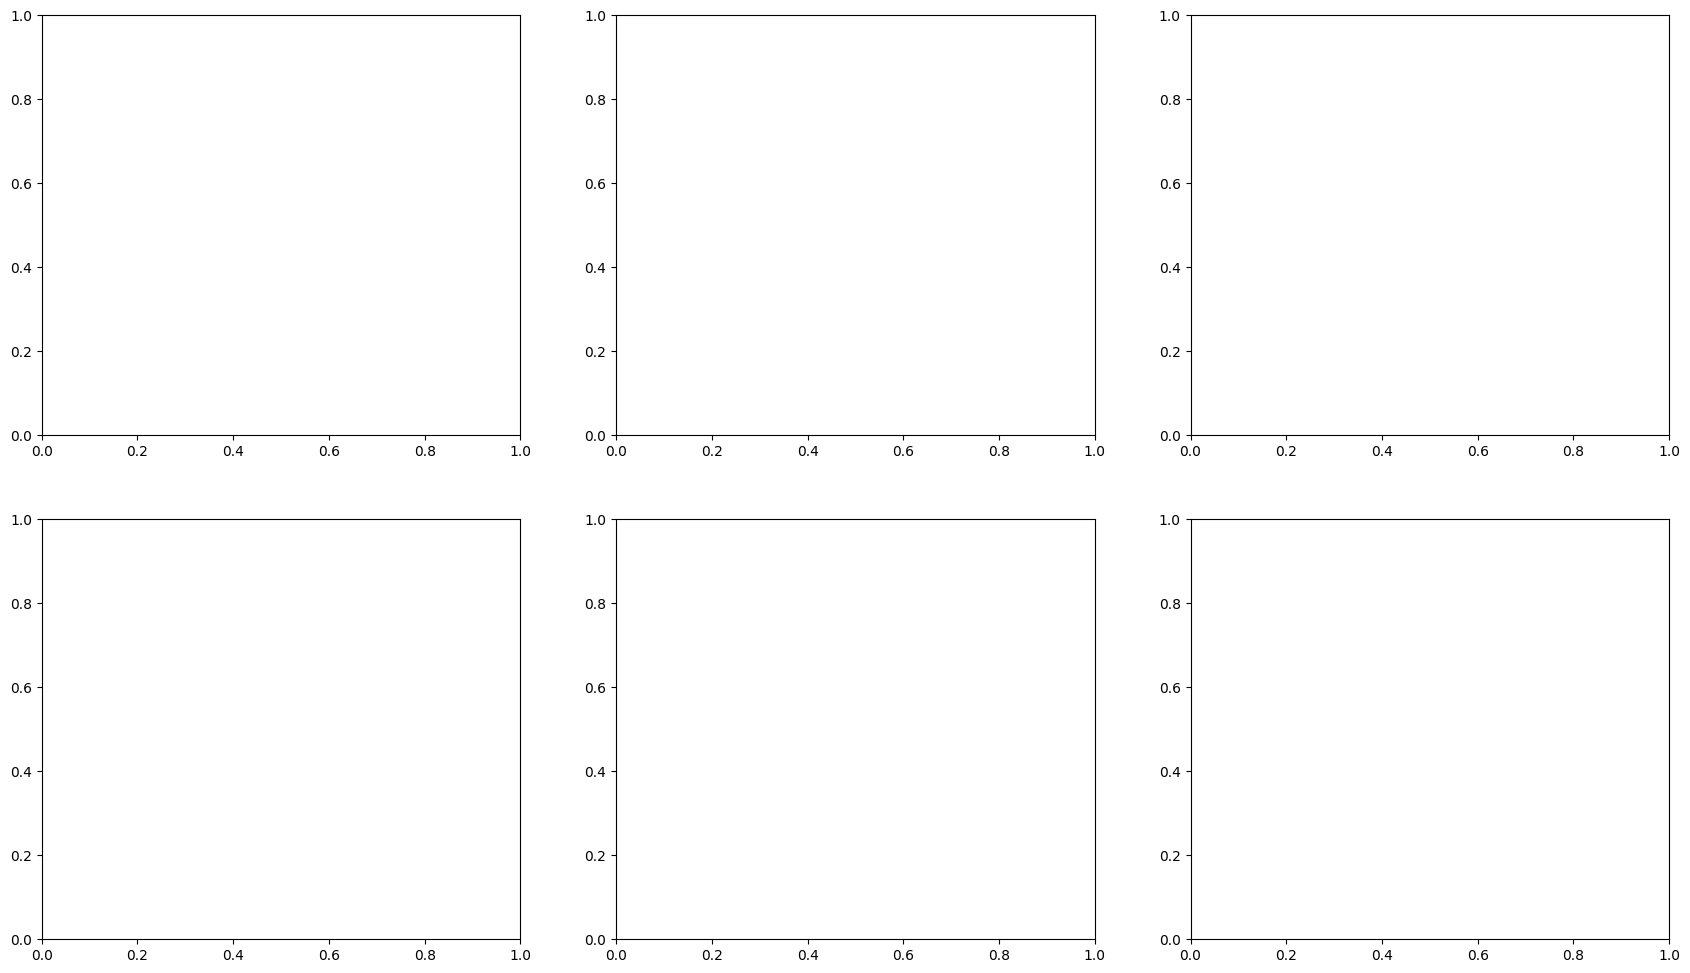

In [ ]:
import matplotlib.pyplot as plt

print("\n-- Computing UMAPs --------------------------------------------------")

fig, axes = plt.subplots(2, 3, figsize=(21, 12))

for col, (rep_key, rep_label) in enumerate(rep_info):
    print(f"  {rep_label}...")

    sc.pp.neighbors(
        adata_hvg, use_rep=rep_key, n_neighbors=15,
        key_added=f"nbrs_{rep_key}", random_state=RANDOM_STATE,
    )
    sc.tl.umap(
        adata_hvg, neighbors_key=f"nbrs_{rep_key}",
        random_state=RANDOM_STATE,
    )
    # Store before next iteration overwrites X_umap
    adata_hvg.obsm[f"X_umap_{rep_key}"] = adata_hvg.obsm["X_umap"].copy()

    sc.pl.umap(
        adata_hvg, color=CELL_TYPE_KEY,
        title=f"{rep_label} -- cell type",
        frameon=False, size=1,
        ax=axes[0, col], show=False,
    )
    sc.pl.umap(
        adata_hvg, color="condition",
        title=f"{rep_label} -- ADJ vs PDAC",
        frameon=False, size=1,
        ax=axes[1, col], show=False,
    )

plt.suptitle(
    "UMAP: scGPT  |  PCA-50  |  Raw-HVG\n"
    "(row 1 = cell type   row 2 = condition)",
    fontsize=14, y=1.02,
)
plt.tight_layout()
plt.savefig(OUTPUT_PLOT, dpi=150, bbox_inches="tight")
plt.show()
print(f"\n  Saved -> {OUTPUT_PLOT}")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
print(f"\n-- Saving -> {OUTPUT_H5AD}")
adata_hvg.write_h5ad(OUTPUT_H5AD)
print("Done.")


-- Saving -> /content/drive/MyDrive/CompGenProject/data/PDAC_ADJ_embeddings.h5ad
Done.
